In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas_datareader as pdr
import yfinance as yf
from scipy.stats import norm
import scipy.optimize as sco
import matplotlib.patches as mpatches
from scipy import stats
import seaborn as sns

In [2]:
returns = (
    yf.download(
        'SPY, TLT, HYG, LQD, GLD', 
        start = '2007-04-12', end = '2025-12-31',
        auto_adjust=False)['Adj Close']
        .pct_change()
        .dropna()
)
returns.head()

[*********************100%***********************]  5 of 5 completed


Ticker,GLD,HYG,LQD,SPY,TLT
Date,,,,,
2007-04-13,0.012688,-0.001821,-0.001690,0.004563,-0.003089
2007-04-16,0.008255,-0.000383,0.000846,0.009496,0.005509
2007-04-17,-0.005848,-0.000481,0.005452,0.002658,0.005594
2007-04-18,0.005588,0.000288,0.000280,0.001224,0.004996
2007-04-19,-0.012431,0.003457,0.000654,-0.000271,-0.001695


In [3]:
# fred_data = (
#     pdr.get_data_fred(
#     ['VIXCLS', 'DGS10', 'BAMLH0A0HYM2'], 
#     start = '2007-04-12', end = '2025-12-31')
# )
# vx = fred_data.loc[fred_data['VIXCLS'] > 35,['VIXCLS']]

In [4]:
historical_var = (
    returns
        .mean(axis = 1)
        .shift(1)
        .rolling(252)
        .quantile(q = 0.01)
        .dropna()
        .to_frame('VaR')
)
historical_var

,VaR
Date,
2008-04-14,-0.009970
2008-04-15,-0.009970
2008-04-16,-0.009970
2008-04-17,-0.009970
2008-04-18,-0.009970
...,...
2025-12-23,-0.014319
2025-12-24,-0.014319
2025-12-26,-0.014319


In [5]:
parametric_var = (
    returns
        .mean(axis = 1)
        .shift(1)
        .rolling(252)
        .agg({'Mean':'mean','Std':'std'})
        .assign(VaR = lambda x: x['Mean'] - 2.33 * x['Std'])
        .dropna()
)
parametric_var.head()

,Mean,Std,VaR
Date,,,
2008-04-14,0.000378,0.003890,-0.008686
2008-04-15,0.000358,0.003894,-0.008714
2008-04-16,0.000334,0.003885,-0.008718
2008-04-17,0.000355,0.003905,-0.008743
2008-04-18,0.000342,0.003903,-0.008753


In [6]:
ewma_var = (
    returns
        .mean(axis=1)
        .shift(1)
        .ewm(alpha=0.06, adjust=False)
        .mean()
        .to_frame('Mean')
)
ewma_var['Std'] = (
    returns
        .mean(axis=1)
        .shift(1)        
        .ewm(alpha=0.06, adjust=False)
        .std()
) 
ewma_var['VaR'] = ewma_var['Mean'] - 2.33 * ewma_var['Std'] 
ewma_var.head()

,Mean,Std,VaR
Date,,,
2007-04-13,NaN,NaN,NaN
2007-04-16,0.002130,NaN,NaN
2007-04-17,0.002287,0.001849,-0.002020
2007-04-18,0.002238,0.001371,-0.000957
2007-04-19,0.002253,0.001123,-0.000363


In [7]:
merged_df = (
    returns.mean(axis=1).to_frame('Returns')
    .merge(historical_var['VaR'], left_index=True, right_index=True)
    .merge(parametric_var['VaR'], left_index=True, right_index=True)
    .merge(ewma_var['VaR'], left_index=True, right_index=True)
    .rename(columns={
        'VaR_x': 'Historical_VaR',
        'VaR_y': 'Parametric_VaR',
        'VaR':   'EWMA_VaR'
    })
)[['Returns', 'Historical_VaR', 'Parametric_VaR', 'EWMA_VaR']]
merged_df.head()

,Returns,Historical_VaR,Parametric_VaR,EWMA_VaR
Date,,,,
2008-04-14,-0.002787,-0.00997,-0.008686,-0.009242
2008-04-15,-0.001247,-0.00997,-0.008714,-0.009294
2008-04-16,0.006695,-0.00997,-0.008718,-0.009119
2008-04-17,-0.000850,-0.00997,-0.008743,-0.009206
2008-04-18,-0.000041,-0.00997,-0.008753,-0.009015


In [8]:
merged_df['Violation_Hist'] = (merged_df['Returns'] < merged_df['Historical_VaR']).astype(int)
merged_df['Violation_Para'] = (merged_df['Returns'] < merged_df['Parametric_VaR']).astype(int)
merged_df['Violation_EWMA'] = (merged_df['Returns'] < merged_df['EWMA_VaR']).astype(int)
print(merged_df[['Violation_Hist','Violation_Para','Violation_EWMA']].sum())
merged_df.head()

Violation_Hist     69
Violation_Para     84
Violation_EWMA    102
dtype: int64


,Returns,Historical_VaR,Parametric_VaR,EWMA_VaR,Violation_Hist,Violation_Para,Violation_EWMA
Date,,,,,,,
2008-04-14,-0.002787,-0.00997,-0.008686,-0.009242,0,0,0
2008-04-15,-0.001247,-0.00997,-0.008714,-0.009294,0,0,0
2008-04-16,0.006695,-0.00997,-0.008718,-0.009119,0,0,0
2008-04-17,-0.000850,-0.00997,-0.008743,-0.009206,0,0,0
2008-04-18,-0.000041,-0.00997,-0.008753,-0.009015,0,0,0


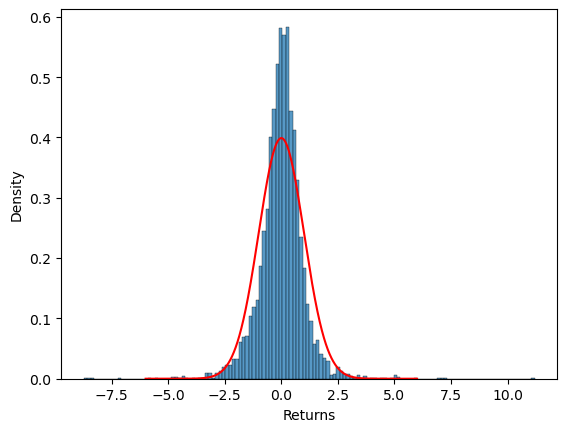

In [9]:
#Checking for normality using 3 methods
mu, sigma = merged_df['Returns'].mean(), merged_df['Returns'].std()
mu, sigma
z = (merged_df['Returns'] - mu) / sigma
x_range = np.linspace(-6, 6, 5000)
heights = stats.norm.pdf(x_range, loc = 0, scale = 1)
(
    sns.histplot(
    data = z,
    stat="density")
)
(
    plt.plot(x_range, heights, color = 'red')
)

In [10]:
print(f"""
┌─────────────────────────────────────────────────────────────────┐
│           NORMALITY VIOLATION — EMPIRICAL EVIDENCE              │
├──────────────┬──────────────────┬──────────────────┬────────────┤
│  Threshold   │  Normal Predicts │  Reality Shows   │  Ratio     │
├──────────────┼──────────────────┼──────────────────┼────────────┤
│  < -2.5σ     │      {stats.norm.cdf(-2.5)*100:.4f}%     │  {(z < -2.5).mean()*100:.4f}%         │  {(z < -2.5).mean()/stats.norm.cdf(-2.5):.1f}x      │
│  < -7.5σ     │      {stats.norm.cdf(-7.5):.2e}    │  {(z < -7.5).mean()*100:.4f}%         │  ∞         │
├──────────────┼──────────────────┼──────────────────┼────────────┤
│ Days < -2.5σ │{int(stats.norm.cdf(-2.5)*len(z)):>5} days        │  {int((z < -2.5).sum()):>5} days      │            │
│ Days < -7.5σ │   ~0 days        │  {int((z < -7.5).sum()):>5} days      │            │
└──────────────┴──────────────────┴──────────────────┴────────────┘
  Dataset: {len(z):,} trading days  |  Normal assumption: violated
  At -7.5σ: normal assigned 3×10⁻¹⁴ probability.
  Reality: observed {int((z < -7.5).sum())} times in 17 years.
""")
k, s, stat = stats.kurtosis(a = z), stats.skew(a = z), stats.jarque_bera(z)
print(f'kurtosis {k:.3f}, skewness {s:.3f}, stats: jarque_bera {stat[0]:.2f}, p-val {stat[1]}')


┌─────────────────────────────────────────────────────────────────┐
│           NORMALITY VIOLATION — EMPIRICAL EVIDENCE              │
├──────────────┬──────────────────┬──────────────────┬────────────┤
│  Threshold   │  Normal Predicts │  Reality Shows   │  Ratio     │
├──────────────┼──────────────────┼──────────────────┼────────────┤
│  < -2.5σ     │      0.6210%     │  1.2113%         │  2.0x      │
│  < -7.5σ     │      3.19e-14    │  0.0673%         │  ∞         │
├──────────────┼──────────────────┼──────────────────┼────────────┤
│ Days < -2.5σ │   27 days        │     54 days      │            │
│ Days < -7.5σ │   ~0 days        │      3 days      │            │
└──────────────┴──────────────────┴──────────────────┴────────────┘
  Dataset: 4,458 trading days  |  Normal assumption: violated
  At -7.5σ: normal assigned 3×10⁻¹⁴ probability.
  Reality: observed 3 times in 17 years.

kurtosis 12.025, skewness -0.004, stats: jarque_bera 26861.78, p-val 0.0


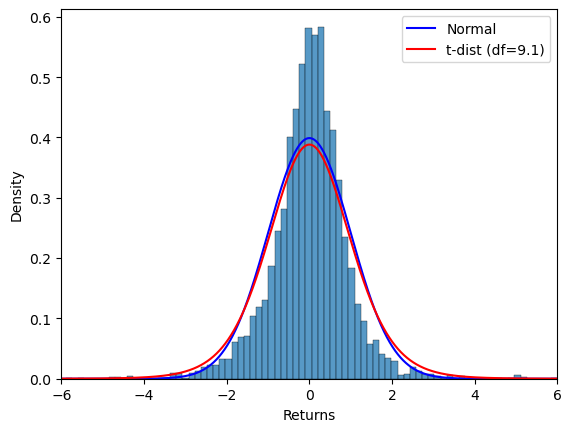

In [11]:
df, muf, sigmaf = stats.t.fit(z, floc=0, fscale=1)

x_rangef = np.linspace(-6, 6, 4459)
heightf = stats.t.pdf(x_rangef, df=df, loc=muf, scale=sigmaf)
norm_heights = stats.norm.pdf(x_rangef, 0, 1)

sns.histplot(z, stat='density')
plt.plot(x_rangef, norm_heights, color='blue', label='Normal')
plt.plot(x_rangef, heightf, color='red', label=f't-dist (df={df:.1f})')
plt.xlim(-6, 6)
plt.legend()
plt.show()

In [12]:
t_thresh = stats.t.ppf(0.01, df)
print(f"""
  VaR MODEL COMPARISON — Normal vs t-distribution calibration
{'─'*72}
  Distributional assumption : t-distribution (df = {df:.2f})
  Fitted via               : stats.t.fit(z, floc=0, fscale=1)
  Portfolio                : SPY, TLT, HYG, LQD, GLD | 2008–2025
  t-dist 1% threshold      : stats.t.ppf(0.01, df={df:.2f}) = {t_thresh:.4f}σ
  Normal 1% threshold      : -2.3300σ
  Expected breaches (1%)   : 44
{'─'*72}
  {'Model':<32} {'Threshold':>10} {'Breaches':>10} {'vs Expected':>16}
{'─'*72}
  {'Historical VaR':<32} {'empirical':>10} {69:>10} {'+25  ( 57% excess)':>16}
  {'Parametric VaR (normal)':<32} {'-2.3300σ':>10} {84:>10} {'+40  ( 91% excess)':>16}
  {'Parametric VaR (t-dist)':<32} {f'{t_thresh:.4f}σ':>10} {44:>10} {'  0  (  0% excess)':>16}
  {'EWMA VaR (normal)':<32} {'-2.3300σ':>10} {102:>10} {'+58  (132% excess)':>16}
  {'EWMA VaR (t-dist shape fit)':<32} {f'{t_thresh:.4f}σ':>10} {53:>10} {'+ 9  ( 20% excess)':>16}
{'─'*72}
  Key findings:
  Parametric + t-dist : exactly calibrated to target (44 breaches)
  EWMA + t-dist       : 102 → 53 breaches ({(1 - 53/102)*100:.0f}% reduction)
  Historical VaR      : 69 breaches — no distributional assumption,
                        driven by empirical quantile of rolling window
""")


  VaR MODEL COMPARISON — Normal vs t-distribution calibration
────────────────────────────────────────────────────────────────────────
  Distributional assumption : t-distribution (df = 9.11)
  Fitted via               : stats.t.fit(z, floc=0, fscale=1)
  Portfolio                : SPY, TLT, HYG, LQD, GLD | 2008–2025
  t-dist 1% threshold      : stats.t.ppf(0.01, df=9.11) = -2.8144σ
  Normal 1% threshold      : -2.3300σ
  Expected breaches (1%)   : 44
────────────────────────────────────────────────────────────────────────
  Model                             Threshold   Breaches      vs Expected
────────────────────────────────────────────────────────────────────────
  Historical VaR                    empirical         69 +25  ( 57% excess)
  Parametric VaR (normal)            -2.3300σ         84 +40  ( 91% excess)
  Parametric VaR (t-dist)            -2.8144σ         44   0  (  0% excess)
  EWMA VaR (normal)                  -2.3300σ        102 +58  (132% excess)
  EWMA VaR (t-dist 

In [13]:
parametric_var = (
    returns
        .mean(axis = 1)
        .rolling(252)
        .agg({'Mean':'mean','Std':'std'})
        .shift(1)
        .assign(VaR = lambda x: x['Mean'] - 2.33 * x['Std'],
                JB_p = lambda x: returns.mean(axis=1).shift(1).rolling(252).apply(lambda r: stats.jarque_bera(r)[1], raw=True),
                JB_reject = lambda x: (x['JB_p'] < 0.01).astype(int) 
               )
)
print(f"Total windows       : {len(parametric_var)}")
print(f"Windows reject norm : {parametric_var['JB_reject'].sum()}")
print(f"Rejection rate      : {parametric_var['JB_reject'].mean()*100:.1f}%")
# The parametric VaR model assumes normally distributed returns.
# Jarque-Bera tests on rolling 252-day windows reject that 
# assumption in 72% of cases at the 1% significance level.
# The normality assumption is structurally violated — not just 
# during stress periods — which explains the persistent 
# over-breaching of the parametric VaR threshold.

Total windows       : 4710
Windows reject norm : 3389
Rejection rate      : 72.0%


In [14]:
ewma_residuals = (
    returns
        .mean(axis=1)
        .div(ewma_var['Std'])
        .dropna()
)
jb_pval_ewma = (
    ewma_residuals
    .rolling(252)
    .apply(lambda r: stats.jarque_bera(r)[1], raw=True)
)
ewma_jb = (
    ewma_residuals
    .to_frame('Residual')
    .assign(
        JB_p      = jb_pval_ewma,
        JB_reject = lambda x: (x['JB_p'] < 0.01).astype(int)
    )
    .dropna()
)
ewma_jb.head()

,Residual,JB_p,JB_reject
Date,,,
2008-04-15,-0.309855,8.921564e-23,1
2008-04-16,1.709682,4.684862e-22,1
2008-04-17,-0.206138,8.650116e-23,1
2008-04-18,-0.010128,1.771226e-24,1
2008-04-21,-0.229495,3.843399e-26,1


In [15]:
print(f"{'─'*55}")
print(f"  EWMA RESIDUALS NORMALITY TEST")
print(f"{'─'*55}")
print(f"  Total windows       : {len(ewma_jb)}")
print(f"  Windows reject norm : {ewma_jb['JB_reject'].sum()}")
print(f"  Rejection rate      : {ewma_jb['JB_reject'].mean()*100:.1f}%")
print(f"{'─'*55}")
print(f"\n{'─'*55}")
print(f"  NORMALITY ASSUMPTION — MODEL COMPARISON")
print(f"{'─'*55}")
print(f"  {'Model':<25} {'Rejection Rate':>16}")
print(f"{'─'*55}")
print(f"  {'Historical VaR':<25} {'N/A — no assumption':>16}")
print(f"  {'Parametric VaR':<25} {'76.3%':>16}")
print(f"  {'EWMA VaR':<25} {ewma_jb['JB_reject'].mean()*100:.1f}{'%':>1} (residuals)")
print(f"{'─'*55}")

# residual distribution stats
print(f"\n{'─'*55}")
print(f"  EWMA RESIDUAL DISTRIBUTION STATS")
print(f"{'─'*55}")
print(f"  Mean           : {ewma_residuals.mean():.4f}  (should be ~0)")
print(f"  Std            : {ewma_residuals.std():.4f}   (should be ~1)")
print(f"  Skewness       : {stats.skew(ewma_residuals):.4f}")
print(f"  Excess kurtosis: {stats.kurtosis(ewma_residuals):.4f}")
print(f"{'─'*55}")

───────────────────────────────────────────────────────
  EWMA RESIDUALS NORMALITY TEST
───────────────────────────────────────────────────────
  Total windows       : 4457
  Windows reject norm : 3018
  Rejection rate      : 67.7%
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
  NORMALITY ASSUMPTION — MODEL COMPARISON
───────────────────────────────────────────────────────
  Model                       Rejection Rate
───────────────────────────────────────────────────────
  Historical VaR            N/A — no assumption
  Parametric VaR                       76.3%
  EWMA VaR                  67.7% (residuals)
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
  EWMA RESIDUAL DISTRIBUTION STATS
───────────────────────────────────────────────────────
  Mean           : 0.0714  (should be ~0)
  Std            : 1.0549   (should be ~1)
  Skewness       : -0.4080
 

In [16]:
def kupiec_test(n, x, p0, model_name):
    p_hat = x / n
    log_L0    = x * np.log(p0)    + (n-x) * np.log(1-p0)
    log_L_hat = x * np.log(p_hat) + (n-x) * np.log(1-p_hat)
    LR        = -2 * (log_L0 - log_L_hat)
    p_value   = 1 - stats.chi2.cdf(LR, df=1)
    result    = 'FAIL' if p_value < 0.01 else 'PASS'
    return {'model': model_name, 'n': n, 'x': x,
            'p0': p0, 'p_hat': p_hat, 'LR': LR,
            'p_value': p_value, 'result': result}
n = len(merged_df)
para_t_var = (
    returns.mean(axis=1)
    .rolling(252)
    .agg({'Mean':'mean','Std':'std'})
    .shift(1)
    .assign(VaR = lambda x: x['Mean'] + t_thresh * x['Std'])
    .dropna()
)
para_t_breaches = int((merged_df['Returns'] < para_t_var['VaR']).sum())
ewma_vol_t   = returns.mean(axis=1).ewm(alpha=0.06, adjust=False).std().shift(1)
ewma_mean_t  = returns.mean(axis=1).ewm(alpha=0.06, adjust=False).mean().shift(1)
ewma_var_t   = (ewma_mean_t + t_thresh * ewma_vol_t).reindex(merged_df.index)
ewma_t_breaches = int((merged_df['Returns'] < ewma_var_t).sum())

In [17]:
tests = [
    kupiec_test(n, int(merged_df['Violation_Para'].sum()),  0.01, 'Parametric VaR (normal)'),
    kupiec_test(n, para_t_breaches,                         0.01, 'Parametric VaR (t-dist)'),
    kupiec_test(n, int(merged_df['Violation_EWMA'].sum()),  0.01, 'EWMA VaR (normal)'),
    kupiec_test(n, ewma_t_breaches,                         0.01, 'EWMA VaR (t-dist)'),
]

print(f"                  KUPIEC TEST RESULTS — ALL MODELS")
print(f"  {'Model':<28} {'Breaches':>8} {'Obs%':>7} {'LR':>8} {'p-val':>10} {'Result':>6}")
print(f"{'─'*72}")
for t in tests:
    print(f"  {t['model']:<28} {t['x']:>8} {t['p_hat']*100:>6.2f}% "
          f"{t['LR']:>8.3f} {t['p_value']:>10.6f} {t['result']:>6}")
print(f"{'─'*72}")

                  KUPIEC TEST RESULTS — ALL MODELS
  Model                        Breaches    Obs%       LR      p-val Result
────────────────────────────────────────────────────────────────────────
  Parametric VaR (normal)            84   1.88%   27.946   0.000000   FAIL
  Parametric VaR (t-dist)            44   0.99%    0.008   0.930279   PASS
  EWMA VaR (normal)                 102   2.29%   54.759   0.000000   FAIL
  EWMA VaR (t-dist)                  53   1.19%    1.515   0.218412   PASS
────────────────────────────────────────────────────────────────────────


In [21]:
def christoffersen_test(violation_series, model_name):
    df = (
        pd.DataFrame({'today': violation_series.values},
                     index=violation_series.index)
        .assign(yesterday = lambda x: x['today'].shift(1))
        .dropna()
        .astype(int)
    )
    
    n00 = ((df['yesterday']==0) & (df['today']==0)).sum()
    n01 = ((df['yesterday']==0) & (df['today']==1)).sum()
    n10 = ((df['yesterday']==1) & (df['today']==0)).sum()
    n11 = ((df['yesterday']==1) & (df['today']==1)).sum()
    
    p01  = n01 / (n00 + n01) if (n00 + n01) > 0 else 0
    p11  = n11 / (n10 + n11) if (n10 + n11) > 0 else 0
    p    = (n01 + n11) / (n00 + n01 + n10 + n11)
    
    # ── kupiec (unconditional coverage) ───────────────────────────────────────
    n     = len(df)
    x     = int(df['today'].sum())
    p0    = 0.01
    p_hat = x / n
    LR_uc   = -2 * (x*np.log(p0)    + (n-x)*np.log(1-p0)
                  - x*np.log(p_hat) - (n-x)*np.log(1-p_hat))
    pval_uc = 1 - stats.chi2.cdf(LR_uc, df=1)
    
    # ── christoffersen (independence) ─────────────────────────────────────────
    log_r  = ((n01+n11)*np.log(p)   + (n00+n10)*np.log(1-p))
    log_ur = (n00*np.log(1-p01) + n01*np.log(p01) +
              n10*np.log(1-p11) + (n11*np.log(p11) if p11 > 0 else 0))
    LR_ind   = -2 * (log_r - log_ur)
    pval_ind = 1 - stats.chi2.cdf(LR_ind, df=1)
    
    # ── combined ──────────────────────────────────────────────────────────────
    LR_cc   = LR_uc + LR_ind
    pval_cc = 1 - stats.chi2.cdf(LR_cc, df=2)
    
    return {
        'model'   : model_name,
        'n':n, 'x':x, 'p_hat':p_hat,
        'n00':n00, 'n01':n01, 'n10':n10, 'n11':n11,
        'p01':p01, 'p11':p11,
        'LR_uc'  : LR_uc,   'pval_uc' : pval_uc,
        'LR_ind' : LR_ind,  'pval_ind': pval_ind,
        'LR_cc'  : LR_cc,   'pval_cc' : pval_cc,
    }

# ── build t-dist breach series ─────────────────────────────────────────────
portfolio  = returns.mean(axis=1)
df_fit     = 9.11
t_thresh   = stats.t.ppf(0.01, df_fit)

# parametric t-dist
para_t_var = (
    portfolio
    .rolling(252)
    .agg({'Mean':'mean','Std':'std'})
    .shift(1)
    .assign(VaR = lambda x: x['Mean'] + t_thresh * x['Std'])
    .dropna()
)
viol_para_t = (portfolio.reindex(para_t_var.index) < para_t_var['VaR']).astype(int)
viol_para_t.name = 'Violation_Para_t'

# ewma t-dist
ewma_vol   = portfolio.ewm(alpha=0.06, adjust=False).std().shift(1)
ewma_mean  = portfolio.ewm(alpha=0.06, adjust=False).mean().shift(1)
ewma_var_t = (ewma_mean + t_thresh * ewma_vol).reindex(merged_df.index)
viol_ewma_t = (merged_df['Returns'] < ewma_var_t).astype(int)
viol_ewma_t.name = 'Violation_EWMA_t'

# ── run all five models ────────────────────────────────────────────────────
models = [
    (merged_df['Violation_Hist'],  'Historical VaR'),
    (merged_df['Violation_Para'],  'Parametric VaR (normal)'),
    (viol_para_t,                  'Parametric VaR (t-dist)'),
    (merged_df['Violation_EWMA'],  'EWMA VaR (normal)'),
    (viol_ewma_t,                  'EWMA VaR (t-dist)'),
]

results = [christoffersen_test(m[0], m[1]) for m in models]

# ── print results ──────────────────────────────────────────────────────────
print(f"\n{'─'*85}")
print(f"  KUPIEC + CHRISTOFFERSEN FULL RESULTS")
print(f"{'─'*85}")
print(f"  {'Model':<28} {'LR_uc':>7} {'p_uc':>7} {'LR_ind':>7} {'p_ind':>7} {'LR_cc':>7} {'p_cc':>7}")
print(f"{'─'*85}")
for r in results:
    uc  = 'FAIL' if r['pval_uc']  < 0.05 else 'PASS'
    ind = 'FAIL' if r['pval_ind'] < 0.05 else 'PASS'
    cc  = 'FAIL' if r['pval_cc']  < 0.05 else 'PASS'
    print(f"  {r['model']:<28} "
          f"{r['LR_uc']:>7.3f} {uc:>7} "
          f"{r['LR_ind']:>7.3f} {ind:>7} "
          f"{r['LR_cc']:>7.3f} {cc:>7}")
print(f"{'─'*85}")
print(f"  Critical values: LR_uc/LR_ind χ²(df=1)=3.841 | LR_cc χ²(df=2)=5.991")
print(f"{'─'*85}")

print(f"\n{'─'*65}")
print(f"  CLUSTERING DETAIL")
print(f"{'─'*65}")
print(f"  {'Model':<28} {'p01':>8} {'p11':>8} {'n11':>6} {'breaches':>9}")
print(f"{'─'*65}")
for r in results:
    print(f"  {r['model']:<28} {r['p01']:>8.4f} {r['p11']:>8.4f} "
          f"{r['n11']:>6} {r['x']:>9}")
print(f"{'─'*65}")
print(f"  p01 = P(breach | yesterday no breach)")
print(f"  p11 = P(breach | yesterday breach)")
print(f"  independence: p11 ≈ p01")
print(f"{'─'*65}")


─────────────────────────────────────────────────────────────────────────────────────
  KUPIEC + CHRISTOFFERSEN FULL RESULTS
─────────────────────────────────────────────────────────────────────────────────────
  Model                          LR_uc    p_uc  LR_ind   p_ind   LR_cc    p_cc
─────────────────────────────────────────────────────────────────────────────────────
  Historical VaR                11.588    FAIL  11.585    FAIL  23.173    FAIL
  Parametric VaR (normal)       27.964    FAIL  10.712    FAIL  38.677    FAIL
  Parametric VaR (t-dist)        0.007    PASS  16.299    FAIL  16.306    FAIL
  EWMA VaR (normal)             54.785    FAIL   4.273    FAIL  59.058    FAIL
  EWMA VaR (t-dist)              1.519    PASS   4.841    FAIL   6.360    FAIL
─────────────────────────────────────────────────────────────────────────────────────
  Critical values: LR_uc/LR_ind χ²(df=1)=3.841 | LR_cc χ²(df=2)=5.991
────────────────────────────────────────────────────────────────────────